In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/ml-ai-hackathon-2026/sample_submission.csv
/kaggle/input/competitions/ml-ai-hackathon-2026/publisher_summary.csv
/kaggle/input/competitions/ml-ai-hackathon-2026/yearly_trends.csv
/kaggle/input/competitions/ml-ai-hackathon-2026/genre_summary.csv
/kaggle/input/competitions/ml-ai-hackathon-2026/platform_summary.csv
/kaggle/input/competitions/ml-ai-hackathon-2026/train_games.csv
/kaggle/input/competitions/ml-ai-hackathon-2026/test_features.csv


## Import all Data_set

In [2]:
df_train=pd.read_csv(r'/kaggle/input/competitions/ml-ai-hackathon-2026/train_games.csv')
df_test=pd.read_csv(r"/kaggle/input/competitions/ml-ai-hackathon-2026/test_features.csv")
df_sample_submission=pd.read_csv(r"/kaggle/input/competitions/ml-ai-hackathon-2026/sample_submission.csv")
df_yearly_trends=pd.read_csv(r"/kaggle/input/competitions/ml-ai-hackathon-2026/yearly_trends.csv")
df_publisher_summary=pd.read_csv(r"/kaggle/input/competitions/ml-ai-hackathon-2026/publisher_summary.csv")
df_platform_summary=pd.read_csv(r"/kaggle/input/competitions/ml-ai-hackathon-2026/platform_summary.csv")
df_genre_summary=pd.read_csv(r"/kaggle/input/competitions/ml-ai-hackathon-2026/genre_summary.csv")

In [3]:
df_train.head()

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,...,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,publisher_is_developer,internal_build_id,marketing_campaign_type,day_one_patch_size_mb
0,G000019,Night in the Saga,Atari 2600,Console,Atari,2,Adventure,1985,Take-Two Interactive,Raw Fury,...,0,0,0,0,16.5,72.7,0,E571DCF3,NaN,7534
1,G000129,Metal Gear Legend,Atari 2600,Console,Atari,2,Idle/Clicker,1985,Nintendo,Larian Studios,...,0,0,0,0,10.6,44.5,0,DA796E03,Campaign_C,13313
2,G000192,FIFA 2024,NES,Console,Nintendo,3,Sports,1985,FromSoftware,Activision Blizzard,...,0,0,0,0,14.0,63.1,0,7C30DA4B,Campaign_C,11487
3,G000200,Tales of World,NES,Console,Nintendo,3,Role-Playing,1985,Ubisoft,Toby Fox,...,0,0,0,0,66.2,152.1,0,D75B1F62,NaN,12498
4,G000254,God of Shadow,PC,PC,Various,0,Action,1985,Nintendo,Nintendo,...,0,0,0,0,10.4,27.4,1,049CF258,Campaign_B,1917


In [4]:
df_test.head()

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,...,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,publisher_is_developer,internal_build_id,marketing_campaign_type,day_one_patch_size_mb
0,G016973,World of Warcraft: Eternal,Mobile (Android),Mobile,Google,0,MMORPG,2024,Double Fine,Double Fine,...,0,0,0,0,179.1,843.6,1,AFC3DF21,Campaign_C,2770
1,G011036,Counter-Strike : Redux,Mobile (Android),Mobile,Google,0,Shooter,2023,Unknown Worlds,Unknown Worlds,...,1,0,0,0,6.1,17.8,1,488E1537,Campaign_A,10980
2,G000593,Euro Truck Simulator 2,PC,PC,Various,0,Simulation,2021,Devolver Digital,Devolver Digital,...,0,0,0,0,13.2,61.4,1,40541EDB,Campaign_A,12403
3,G013281,Rise of the Reborn,Stadia,Streaming,Google,9,Action,2023,Remedy Entertainment,Remedy Entertainment,...,0,0,0,0,10.1,27.2,1,BAF5660F,Campaign_C,14374
4,G004160,Professor Layton and the Saga,PlayStation 4,Console,Sony,8,Puzzle,2023,Double Fine,Double Fine,...,0,0,0,0,8.4,21.5,1,21D7C371,Campaign_A,5114


In [5]:
df_sample_submission.head()

,game_id,estimated_revenue_million_usd
0,G016973,0.0
1,G011036,0.0
2,G000593,0.0
3,G013281,0.0
4,G004160,0.0


In [6]:

df_yearly_trends.head()

,year,genre,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd
0,1985,Action,131,783.051145,74.304300,7.578511,51.500974
1,1985,Action-Adventure,27,565.533333,73.160241,7.389119,54.254196
2,1985,Adventure,38,532.396053,78.325365,7.543377,46.691237
3,1985,Battle Royale,18,913.812778,76.561945,7.447295,38.353663
4,1985,Fighting,50,512.874400,76.523869,7.536959,47.565301


In [7]:
df_publisher_summary.head()

,publisher,publisher_tier,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd,pct_sequel
0,2K Games,AAA,1203,822.521671,75.834215,7.595432,45.095605,0.404821
1,505 Games,AA,564,170.252996,68.025676,6.873583,41.494612,0.393617
2,Activision Blizzard,AAA,1175,790.378817,75.370783,7.559883,45.086469,0.414468
3,Annapurna Interactive,Indie,247,62.848057,71.267194,7.206517,40.280486,0.421053
4,Bandai Namco,AAA,1284,871.279276,75.470130,7.580445,45.565369,0.436916


In [8]:
df_platform_summary.head()

,platform,platform_generation,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd,pct_online_multiplayer
0,Atari 2600,2,1607,936.901307,75.291523,7.514181,59.705971,0.504667
1,Browser,0,2299,0.000000,73.886459,7.392355,-0.001256,0.494563
2,Dreamcast,6,498,806.225141,74.032299,7.439961,59.410105,0.510040
3,Game Boy,4,2107,358.033806,74.297295,7.402152,34.798595,0.495966
4,Game Boy Advance,6,1094,378.153556,73.031227,7.341233,34.670368,0.510969


In [9]:
df_genre_summary.head()

,genre,platform_type,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd,pct_online_multiplayer,pct_dlc_released,pct_microtransactions
0,Action,Browser,330,0.000000,73.179441,7.275458,0.005587,0.281818,0.606061,0.196970
1,Action,Console,3115,964.650408,73.524403,7.356233,59.786596,0.298555,0.637560,0.241413
2,Action,Handheld,1256,439.666250,73.731868,7.387525,34.848484,0.276274,0.621019,0.249204
3,Action,Hybrid,69,1068.038841,73.674123,7.326463,44.876496,0.304348,0.695652,0.260870
4,Action,Mobile,420,193.212643,74.085411,7.423656,2.364155,0.276190,0.638095,0.288095


In [10]:
print(df_train.shape)
print(df_test.shape)
print(df_sample_submission.shape)
print(df_yearly_trends.shape)
print(df_publisher_summary.shape)
print(df_platform_summary.shape)
print(df_genre_summary.shape)

(40000, 34)
(10000, 33)
(10000, 2)
(700, 7)
(51, 8)
(30, 8)
(138, 10)


In [11]:
print(df_train.dtypes,'\n')
print(df_test.dtypes,'\n')
print(df_sample_submission.dtypes,'\n')
print(df_yearly_trends.dtypes,'\n')
print(df_publisher_summary.dtypes,'\n')
print(df_platform_summary.dtypes,'\n')
print(df_genre_summary.dtypes,'\n')

game_id                                object
title                                  object
platform                               object
platform_type                          object
platform_maker                         object
platform_generation                     int64
genre                                  object
year                                    int64
publisher                              object
developer                              object
publisher_region                       object
publisher_tier                         object
esrb_rating                            object
metacritic_score                      float64
user_score                            float64
critic_review_count                   float64
user_review_count                     float64
estimated_revenue_million_usd         float64
launch_price_usd                      float64
is_sequel                               int64
online_multiplayer                      int64
dlc_released                      

In [12]:
print(df_train.isnull().sum()*100/df_train.shape[0],'\n')
print(df_test.isnull().sum()*100/df_test.shape[0],'\n')
print(df_sample_submission.isnull().sum()*100/df_sample_submission.shape[0],'\n')
print(df_yearly_trends.isnull().sum()*100/df_yearly_trends.shape[0],'\n')
print(df_publisher_summary.isnull().sum()*100/df_publisher_summary.shape[0],'\n')
print(df_platform_summary.isnull().sum()*100/df_platform_summary.shape[0],'\n')
print(df_genre_summary.isnull().sum()*100/df_genre_summary.shape[0],'\n')

game_id                                0.0000
title                                  0.0000
platform                               0.0000
platform_type                          0.0000
platform_maker                         0.0000
platform_generation                    0.0000
genre                                  0.0000
year                                   0.0000
publisher                              0.0000
developer                              0.0000
publisher_region                       0.0000
publisher_tier                         0.0000
esrb_rating                            0.0000
metacritic_score                      15.0000
user_score                             0.0000
critic_review_count                   15.0000
user_review_count                     15.0000
estimated_revenue_million_usd          0.0000
launch_price_usd                       0.0000
is_sequel                              0.0000
online_multiplayer                     0.0000
dlc_released                      

In [13]:
df_train['estimated_revenue_million_usd'].describe()

count    40000.000000
mean       628.450379
std       1014.011971
min          0.000000
25%        102.340000
50%        309.305000
75%        749.507500
max      45686.500000
Name: estimated_revenue_million_usd, dtype: float64

## Target Variable Analysis: Estimated Revenue

### Objective
Understand the distribution of the target variable (estimated_revenue_million_usd) before training, in order to determine whether any transformation is needed — we will compare the raw revenue distribution against its log-transformed version.

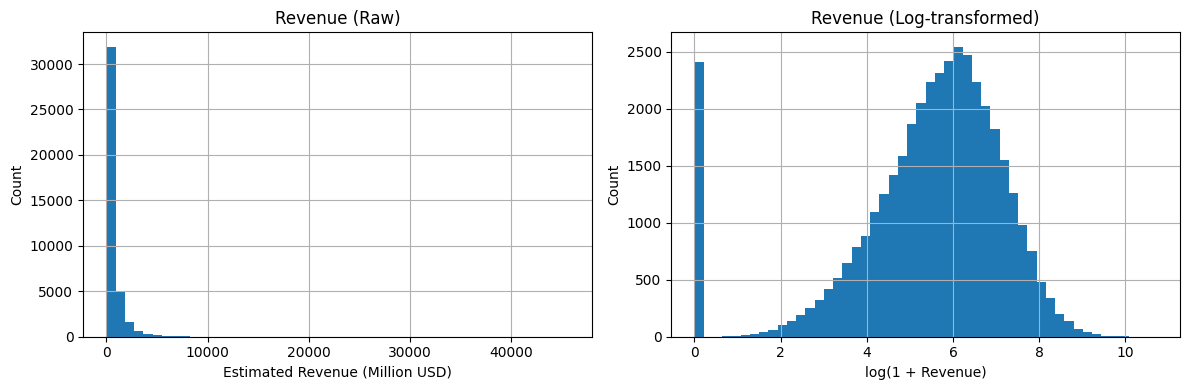

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw revenue histogram
df_train['estimated_revenue_million_usd'].hist(bins=50, ax=axes[0])
axes[0].set_title('Revenue (Raw)')
axes[0].set_xlabel('Estimated Revenue (Million USD)')
axes[0].set_ylabel('Count')

# Log-transformed revenue histogram
np.log1p(df_train['estimated_revenue_million_usd']).hist(bins=50, ax=axes[1])
axes[1].set_title('Revenue (Log-transformed)')
axes[1].set_xlabel('log(1 + Revenue)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Observations

**Raw Revenue Distribution:**
- Distribution is **heavily right-skewed** — majority of games generate low revenue, while a small number of blockbuster titles generate extremely high revenue (up to ~45,000 million USD).
- Mean (~628M) is much higher than the median (~309M), confirming the presence of high-value outliers pulling the mean up.

**Log-transformed Revenue Distribution (`log1p`):**
- After applying `np.log1p()`, the distribution becomes approximately **normal / bell-shaped**.
- A small spike near 0 remains — this corresponds to games with **zero revenue** (e.g., free-to-play Browser games), which is a genuine data pattern, not an error.

### Why this matters
- The competition metric is **RMSLE**, which inherently penalizes errors on a log scale.
- Training directly on raw revenue would let extreme outliers dominate the loss function and bias the model.
- **Decision:** Train the model on `log1p(estimated_revenue_million_usd)` instead of raw revenue, and apply `np.expm1()` to convert predictions back before submission.

In [15]:
print(df_sample_submission.columns,'\n')
print(df_yearly_trends.columns,'\n')
print(df_publisher_summary.columns,'\n')
print(df_platform_summary.columns,'\n')
print(df_genre_summary.columns,'\n')

Index(['game_id', 'estimated_revenue_million_usd'], dtype='object') 

Index(['year', 'genre', 'titles', 'avg_estimated_revenue_million_usd',
       'avg_metacritic_score', 'avg_user_score', 'avg_launch_price_usd'],
      dtype='object') 

Index(['publisher', 'publisher_tier', 'titles',
       'avg_estimated_revenue_million_usd', 'avg_metacritic_score',
       'avg_user_score', 'avg_launch_price_usd', 'pct_sequel'],
      dtype='object') 

Index(['platform', 'platform_generation', 'titles',
       'avg_estimated_revenue_million_usd', 'avg_metacritic_score',
       'avg_user_score', 'avg_launch_price_usd', 'pct_online_multiplayer'],
      dtype='object') 

Index(['genre', 'platform_type', 'titles', 'avg_estimated_revenue_million_usd',
       'avg_metacritic_score', 'avg_user_score', 'avg_launch_price_usd',
       'pct_online_multiplayer', 'pct_dlc_released', 'pct_microtransactions'],
      dtype='object') 



## Categorical Features vs Revenue Analysis

### Objective
Understand how key categorical features in the training data relate to `estimated_revenue_million_usd`. Specifically, we will examine the average revenue across different values of:
- `genre`
- `platform_type`
- `publisher_tier`
- `esrb_rating`

### Why this matters
- Identifying categorical features with strong, consistent differences in average revenue helps determine which ones are likely to be useful predictors for the model.
- This analysis also informs the encoding strategy — features with a natural order (e.g., `publisher_tier`: AAA > AA > Indie) may benefit from ordinal encoding, while features without inherent order (e.g., `genre`) are better suited to one-hot or target encoding.

In [16]:
df_train.groupby('genre')['estimated_revenue_million_usd'].mean()

genre
Action               666.734476
Action-Adventure     391.924259
Adventure            423.531130
Battle Royale        859.211773
Fighting             542.245765
Idle/Clicker         371.693479
MMORPG               428.249116
Misc                 323.743611
Platform             606.371763
Puzzle               281.263622
Racing               608.287553
Rhythm               400.041837
Role-Playing         606.663013
Sandbox             1733.970283
Shooter              862.169527
Simulation           414.532170
Sports              1149.219825
Strategy             299.295719
Survival Horror      364.910696
Visual Novel         102.363438
Name: estimated_revenue_million_usd, dtype: float64

In [17]:
df_train.groupby('platform_type')['estimated_revenue_million_usd'].mean()


platform_type
Browser        0.000000
Console      913.750469
Handheld     386.884974
Hybrid       901.274534
Mobile       160.511936
PC           352.876064
Streaming      0.000000
Name: estimated_revenue_million_usd, dtype: float64

In [18]:
df_train.groupby('publisher_tier')['estimated_revenue_million_usd'].mean()

publisher_tier
AA       169.675886
AAA      809.588494
Indie     73.925564
Name: estimated_revenue_million_usd, dtype: float64

In [19]:
df_train.groupby('esrb_rating')['estimated_revenue_million_usd'].mean()

esrb_rating
AO           641.085420
E            622.541501
E10+         620.897361
M            627.549346
Not Rated    631.368128
T            636.751662
Name: estimated_revenue_million_usd, dtype: float64

## Categorical Features vs Revenue — Findings

### Genre
- **Highest avg revenue:** Sandbox (~1734M), Sports (~1149M), Shooter (~862M), Battle Royale (~859M)
- **Lowest avg revenue:** Visual Novel (~102M), Strategy (~299M), Puzzle (~281M)
- Wide spread across genres (~100M to ~1734M) → `genre` looks like a **strong predictor** of revenue.

### Platform Type
- **Browser** and **Streaming** platforms show **0 average revenue** — consistent with earlier observation that these are likely free-to-play / non-monetized platforms.
- **Console** (~914M) and **Hybrid** (~901M) have the highest average revenue, followed by PC (~353M) and Handheld (~387M).
- **Mobile** is notably low (~161M) despite being a major platform — possibly tied to lower price points or different monetization patterns.
- Clear separation between platform types → `platform_type` is a **strong predictor**.

### Publisher Tier
- Very clear, **monotonic ordering**: AAA (~810M) >> AA (~170M) >> Indie (~74M).
- This is roughly a **10x difference** between AAA and Indie publishers.
- This is one of the **strongest categorical signals** found so far, and supports using an **ordinal encoding** (AAA > AA > Indie) given the natural hierarchy.

### ESRB Rating
- Average revenue across all rating categories is very close (~621M to ~641M) — almost no meaningful variation between AO, E, E10+, M, Not Rated, and T.
- This suggests `esrb_rating` is a **weak predictor** on its own and may not add much standalone signal to the model.

### Summary
| Feature | Predictive Strength | Notes |
|---|---|---|
| `genre` | Strong | Wide variation across categories |
| `platform_type` | Strong | Browser/Streaming = 0, Console/Hybrid highest |
| `publisher_tier` | Very Strong | Clear monotonic AAA > AA > Indie pattern |
| `esrb_rating` | Weak | Minimal variation across categories |

### Next Step
Examine the temporal shift between train (1985–2019) and test (2019–2026) periods to understand how revenue trends evolve over time, and whether `year` needs special handling instead of being used as a raw numeric feature.

In [20]:
df_train.year.unique()

array([1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995,
       1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019])

In [21]:
df_test.year.unique()

array([2024, 2023, 2021, 2020, 2025, 2022, 2026, 2019])

In [22]:
df_train.groupby('year')['estimated_revenue_million_usd'].mean() 

year
1985    732.213849
1986    789.232676
1987    760.982713
1988    754.566536
1989    690.201574
1990    752.381793
1991    768.866032
1992    765.551505
1993    715.679170
1994    731.459212
1995    602.409781
1996    600.755315
1997    641.317327
1998    602.434877
1999    610.546114
2000    562.193506
2001    608.698015
2002    605.758978
2003    603.035422
2004    595.563217
2005    584.886879
2006    663.030665
2007    660.545340
2008    641.068715
2009    600.432756
2010    546.749255
2011    513.315101
2012    589.392292
2013    662.244669
2014    565.699649
2015    633.694464
2016    619.784298
2017    629.695751
2018    540.454861
2019    465.762088
Name: estimated_revenue_million_usd, dtype: float64

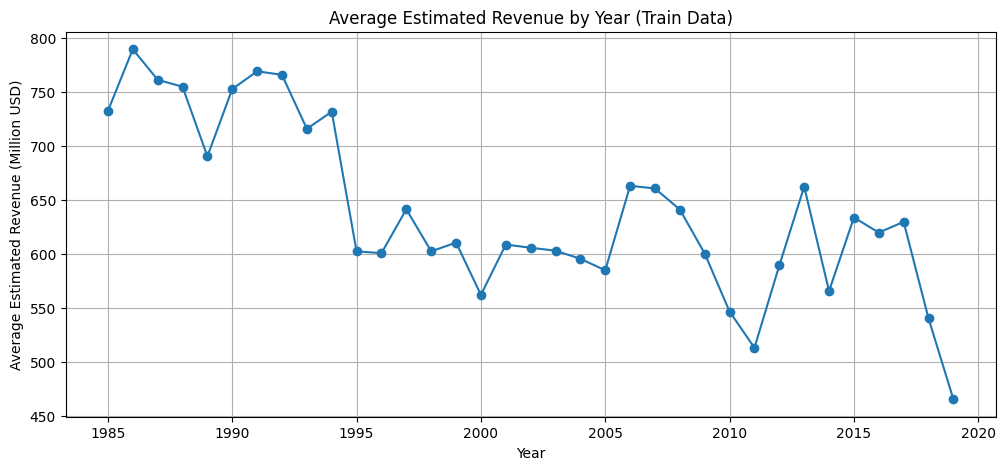

In [23]:
yearly_revenue = df_train.groupby('year')['estimated_revenue_million_usd'].mean()
plt.figure(figsize=(12, 5))
plt.plot(yearly_revenue.index, yearly_revenue.values, marker='o')
plt.title('Average Estimated Revenue by Year (Train Data)')
plt.xlabel('Year')
plt.ylabel('Average Estimated Revenue (Million USD)')
plt.grid(True)
plt.show()

In [24]:
# Yearly trends file ka overview
df_yearly_trends.head(10)

,year,genre,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd
0,1985,Action,131,783.051145,74.304300,7.578511,51.500974
1,1985,Action-Adventure,27,565.533333,73.160241,7.389119,54.254196
2,1985,Adventure,38,532.396053,78.325365,7.543377,46.691237
3,1985,Battle Royale,18,913.812778,76.561945,7.447295,38.353663
4,1985,Fighting,50,512.874400,76.523869,7.536959,47.565301
5,1985,Idle/Clicker,10,408.217000,75.437490,7.650331,42.551609
6,1985,MMORPG,15,585.672667,73.730433,7.372442,55.363286
7,1985,Misc,32,448.122813,70.913801,7.068193,49.325504
8,1985,Platform,52,824.147885,74.691087,7.604785,52.950840
9,1985,Puzzle,34,295.302647,74.632360,7.543896,48.114474


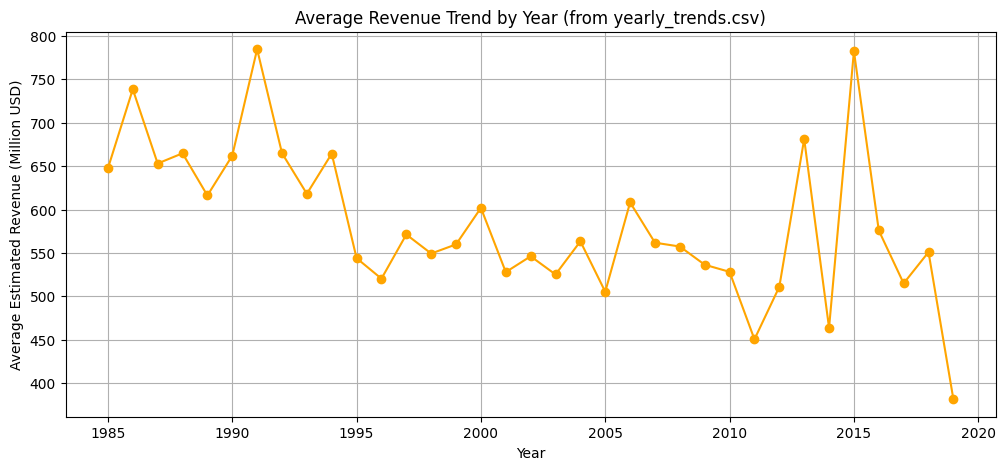

In [25]:
# Overall (all genres combined) year-wise avg revenue trend from yearly_trends.csv
overall_trend = df_yearly_trends.groupby('year')['avg_estimated_revenue_million_usd'].mean()

plt.figure(figsize=(12, 5))
plt.plot(overall_trend.index, overall_trend.values, marker='o', color='orange')
plt.title('Average Revenue Trend by Year (from yearly_trends.csv)')
plt.xlabel('Year')
plt.ylabel('Average Estimated Revenue (Million USD)')
plt.grid(True)
plt.show()

In [26]:
# Compare last 5 years vs first 5 years of train data — to see if trend is changing recently
recent_years = df_yearly_trends[df_yearly_trends['year'] >= 2015]
early_years = df_yearly_trends[df_yearly_trends['year'] <= 1990]

print("Recent years (2015+) avg revenue:", recent_years['avg_estimated_revenue_million_usd'].mean())
print("Early years (<=1990) avg revenue:", early_years['avg_estimated_revenue_million_usd'].mean())

Recent years (2015+) avg revenue: 561.1531439654232
Early years (<=1990) avg revenue: 663.6389442543717


### Observations

Both the train-derived trend and the `yearly_trends.csv` trend show the **same pattern** across years.

This confirms that `yearly_trends.csv` is a **reliable, consistent summary** derived from the same underlying data — not a misleading or fabricated reference table. We can confidently use this file for feature engineering (e.g., merging year+genre level historical averages into train/test).

In [27]:
df=df_train.dtypes
print(df)

game_id                                object
title                                  object
platform                               object
platform_type                          object
platform_maker                         object
platform_generation                     int64
genre                                  object
year                                    int64
publisher                              object
developer                              object
publisher_region                       object
publisher_tier                         object
esrb_rating                            object
metacritic_score                      float64
user_score                            float64
critic_review_count                   float64
user_review_count                     float64
estimated_revenue_million_usd         float64
launch_price_usd                      float64
is_sequel                               int64
online_multiplayer                      int64
dlc_released                      

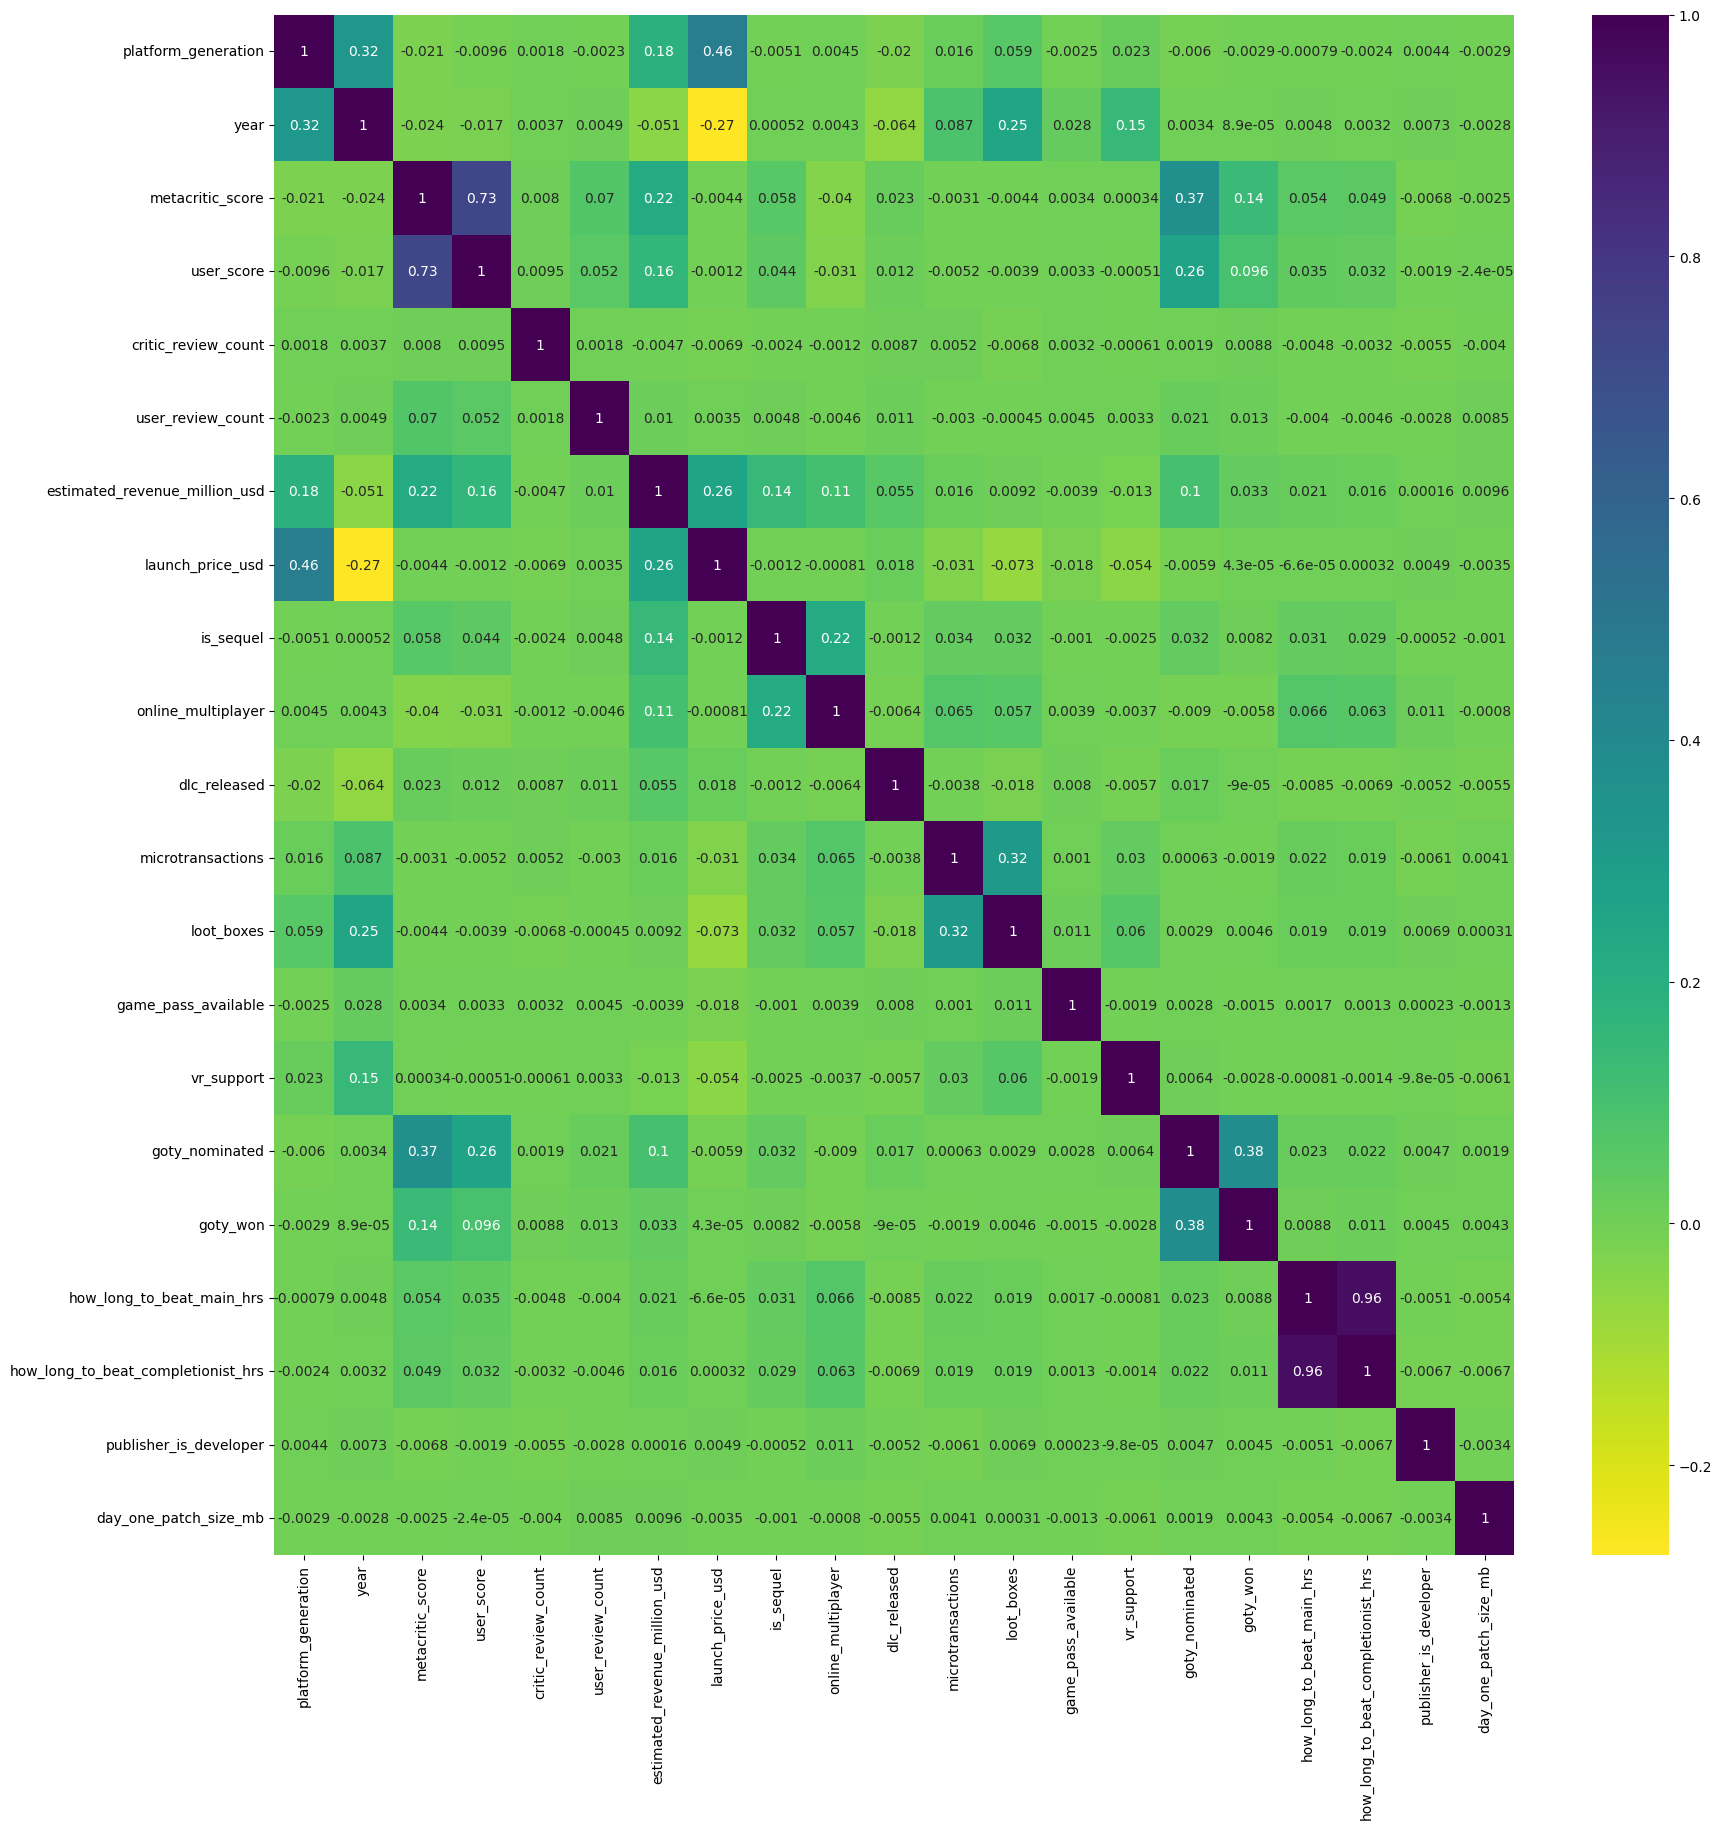

In [28]:
import seaborn as sns
corr=df_train.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='viridis_r',annot=True)
plt.show()

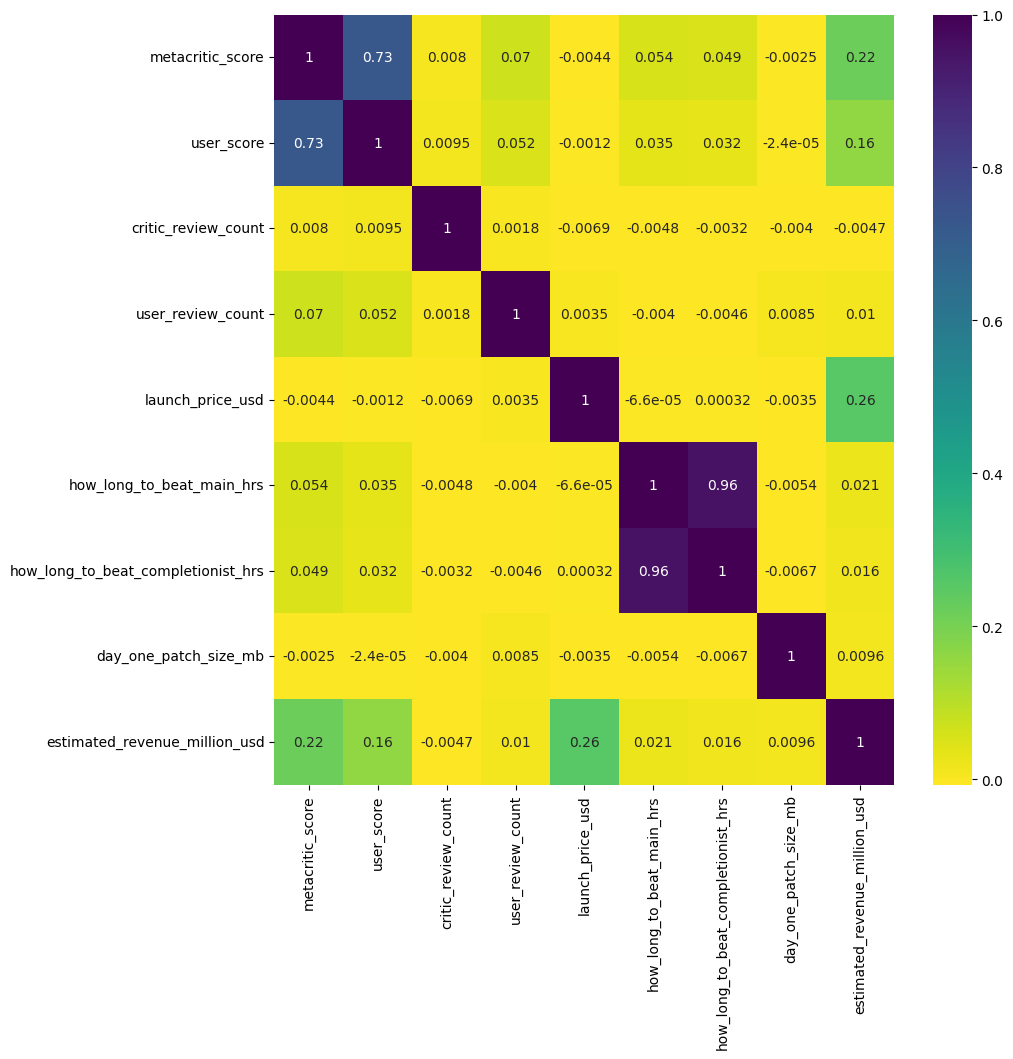

In [29]:


df=df_train[['metacritic_score','user_score','critic_review_count','user_review_count','launch_price_usd','how_long_to_beat_main_hrs','how_long_to_beat_completionist_hrs','day_one_patch_size_mb','estimated_revenue_million_usd']]
corr = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, cmap='viridis_r',annot=True)
plt.show()

### Observations — Full Numeric Correlation Matrix

Using `select_dtypes()` to include all int/float columns (instead of a manual subset) confirms and extends the earlier findings:

**Consistent with previous matrix:**
- `launch_price_usd` (0.26), `metacritic_score` (0.22), and `user_score` (0.16) remain the strongest numeric correlations with revenue — same as before, confirming the earlier result was reliable.

**New columns add weak signal:**
- `platform_generation` (0.18) shows a mild positive correlation — newer console generations tend to associate with somewhat higher revenue.
- `is_sequel` (0.055) is weakly positive — sequels show a slight revenue edge, but not strong.
- `year` shows almost **no linear correlation** with revenue (-0.051), despite the earlier line plot showing a visible year-over-year trend. This suggests the year–revenue relationship is **non-linear / non-monotonic** rather than a simple straight-line trend — correlation only captures linear relationships, so this doesn't contradict the earlier observation, it just means `year` shouldn't be fed in as a raw linear feature.

**Likely red herrings confirmed:**
- Binary flags — `online_multiplayer`, `dlc_released`, `microtransactions`, `loot_boxes`, `game_pass_available`, `vr_support`, `goty_nominated`, `goty_won` — all show **near-zero correlation** (under 0.03) with revenue. These look like meaningful gameplay features on the surface, but individually carry almost no linear predictive signal.

**Multicollinearity noted:**
- `metacritic_score` and `user_score` are still strongly correlated with each other (0.73).
- `microtransactions` and `loot_boxes` show a moderate correlation (0.32) with each other — expected, since loot boxes are usually a form of microtransaction.

### Conclusion
No single numeric feature has a strong linear relationship with revenue. The strongest predictors so far remain **categorical** (`publisher_tier`, `genre`, `platform_type`). Numeric and binary flags will likely contribute more value after feature engineering (e.g., combining them with categorical context, or letting a tree-based model capture non-linear interactions) rather than as standalone linear predictors.

In [30]:
df_train.drop(['title','internal_build_id','game_id'],axis=1)

,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,...,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,publisher_is_developer,marketing_campaign_type,day_one_patch_size_mb
0,Atari 2600,Console,Atari,2,Adventure,1985,Take-Two Interactive,Raw Fury,USA,AAA,...,0,0,0,0,0,16.5,72.7,0,NaN,7534
1,Atari 2600,Console,Atari,2,Idle/Clicker,1985,Nintendo,Larian Studios,Japan,AAA,...,0,0,0,0,0,10.6,44.5,0,Campaign_C,13313
2,NES,Console,Nintendo,3,Sports,1985,FromSoftware,Activision Blizzard,Japan,AAA,...,0,0,0,0,0,14.0,63.1,0,Campaign_C,11487
3,NES,Console,Nintendo,3,Role-Playing,1985,Ubisoft,Toby Fox,France,AAA,...,0,0,0,0,0,66.2,152.1,0,NaN,12498
4,PC,PC,Various,0,Action,1985,Nintendo,Nintendo,Japan,AAA,...,0,0,0,0,0,10.4,27.4,1,Campaign_B,1917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,Xbox One,Console,Microsoft,8,Shooter,2019,Sega,Square Enix,Japan,AAA,...,1,0,0,0,0,9.3,32.4,0,Campaign_B,6515
39996,Stadia,Streaming,Google,9,Adventure,2019,Nintendo,Nintendo,Japan,AAA,...,0,0,0,0,0,7.9,20.1,1,NaN,9577
39997,Browser,Browser,Various,0,Sports,2019,2K Games,Devolver Digital,USA,AAA,...,0,0,0,0,0,22.1,80.2,0,Campaign_A,9507
39998,Mobile (iOS),Mobile,Apple,0,Action,2019,2K Games,2K Games,USA,AAA,...,0,0,0,0,0,8.1,19.2,1,NaN,7760


## Missing Value handling 

In [31]:
from sklearn.model_selection import KFold

def add_oof_target_encoding(train_df, test_df, group_cols, target_col, new_col_name, n_splits=5):
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df[new_col_name] = np.nan
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for tr_idx, val_idx in kf.split(train_df):
        fold_train = train_df.iloc[tr_idx]
        fold_means = fold_train.groupby(group_cols)[target_col].mean()
        val_rows = train_df.iloc[val_idx]
        if len(group_cols) == 1:
            mapped = val_rows[group_cols[0]].map(fold_means)
        else:
            mapped = val_rows.set_index(group_cols).index.map(fold_means)
        train_df.loc[train_df.index[val_idx], new_col_name] = mapped.values

    global_mean = train_df[target_col].mean()
    train_df[new_col_name] = train_df[new_col_name].fillna(global_mean)

    full_means = train_df.groupby(group_cols)[target_col].mean()
    if len(group_cols) == 1:
        test_df[new_col_name] = test_df[group_cols[0]].map(full_means)
    else:
        test_df[new_col_name] = test_df.set_index(group_cols).index.map(full_means)
    test_df[new_col_name] = test_df[new_col_name].fillna(global_mean)

    return train_df, test_df

df_train, df_test = add_oof_target_encoding(df_train, df_test, ['publisher'], 'estimated_revenue_million_usd', 'pub_avg_revenue_oof')
df_train, df_test = add_oof_target_encoding(df_train, df_test, ['platform'], 'estimated_revenue_million_usd', 'plat_avg_revenue_oof')
df_train, df_test = add_oof_target_encoding(df_train, df_test, ['genre', 'platform_type'], 'estimated_revenue_million_usd', 'genre_avg_revenue_oof')
df_train, df_test = add_oof_target_encoding(df_train, df_test, ['year', 'genre'], 'estimated_revenue_million_usd', 'yr_avg_revenue_oof')

print("OOF encoding done. Shape:", df_train.shape)

OOF encoding done. Shape: (40000, 38)


In [32]:
df_train['metacritic_user_diff'] = df_train['metacritic_score'] - df_train['user_score']
df_test['metacritic_user_diff'] = df_test['metacritic_score'] - df_test['user_score']

df_train['price_per_review'] = df_train['launch_price_usd'] / (df_train['critic_review_count'] + 1)
df_test['price_per_review'] = df_test['launch_price_usd'] / (df_test['critic_review_count'] + 1)

df_train['total_review_count'] = df_train['critic_review_count'] + df_train['user_review_count']
df_test['total_review_count'] = df_test['critic_review_count'] + df_test['user_review_count']

print("New features added. Shape:", df_train.shape)

New features added. Shape: (40000, 41)


In [33]:
max_train_year = df_train['year'].max()  # 2019

df_train['years_since_max'] = max_train_year - df_train['year']
df_test['years_since_max'] = max_train_year - df_test['year']

df_train['is_future_game'] = (df_train['year'] > max_train_year).astype(int)  # will be 0 for all train
df_test['is_future_game'] = (df_test['year'] > max_train_year).astype(int)

df_train = df_train.drop(columns=['year'])
df_test = df_test.drop(columns=['year'])

print("Year handling done. Shape:", df_train.shape)

Year handling done. Shape: (40000, 42)


In [34]:
tier_map = {'Indie': 0, 'AA': 1, 'AAA': 2}
df_train['publisher_tier_encoded'] = df_train['publisher_tier'].map(tier_map)
df_test['publisher_tier_encoded'] = df_test['publisher_tier'].map(tier_map)

cols_to_drop = ['publisher', 'developer', 'platform', 'publisher_tier', 'title', 'internal_build_id']
df_train = df_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns])
df_test = df_test.drop(columns=[c for c in cols_to_drop if c in df_test.columns])

onehot_cols = ['genre', 'platform_type', 'esrb_rating', 'marketing_campaign_type', 'publisher_region', 'platform_maker']
onehot_cols_train = [c for c in onehot_cols if c in df_train.columns]
onehot_cols_test = [c for c in onehot_cols if c in df_test.columns]

df_train = pd.get_dummies(df_train, columns=onehot_cols_train)
df_test = pd.get_dummies(df_test, columns=onehot_cols_test)

missing_in_test = set(df_train.columns) - set(df_test.columns) - {'estimated_revenue_million_usd'}
for col in missing_in_test:
    df_test[col] = 0
missing_in_train = set(df_test.columns) - set(df_train.columns)
for col in missing_in_train:
    df_train[col] = 0

print("Encoding done. Train shape:", df_train.shape, "| Test shape:", df_test.shape)

Encoding done. Train shape: (40000, 90) | Test shape: (10000, 89)


In [35]:
from sklearn.model_selection import train_test_split

test_game_ids = df_test['game_id']

X = df_train.drop(columns=['estimated_revenue_million_usd', 'game_id'])
y = np.log1p(df_train['estimated_revenue_million_usd'])
X_test_final = df_test.drop(columns=['game_id'])

X = X.select_dtypes(exclude=['object'])
X_test_final = X_test_final.select_dtypes(exclude=['object'])
X_test_final = X_test_final[X.columns]  # match order

print("Remaining non-numeric:", list(X.select_dtypes(include=['object']).columns))
print("X shape:", X.shape, "| X_test_final shape:", X_test_final.shape)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, "| X_val:", X_val.shape)

Remaining non-numeric: []
X shape: (40000, 88) | X_test_final shape: (10000, 88)
X_train: (32000, 88) | X_val: (8000, 88)


In [36]:
X = df_train.drop(columns=['estimated_revenue_million_usd', 'game_id'])
y = np.log1p(df_train['estimated_revenue_million_usd'])
X_test_final = df_test.drop(columns=['game_id'])
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
cols_to_remove_risky = ['is_future_game', 'price_per_review', 'metacritic_user_diff']
X = X.drop(columns=[c for c in cols_to_remove_risky if c in X.columns])
X_test_final = X_test_final.drop(columns=[c for c in cols_to_remove_risky if c in X_test_final.columns])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X shape after removing risky features:", X.shape)

X shape after removing risky features: (40000, 85)


In [38]:
from catboost import CatBoostRegressor

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import optuna

In [39]:
# to find best learning rate and depth value for our model 
import optuna

def objective(trial):
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),
        'depth': trial.suggest_int('depth', 4, 7),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_seed': 42,
        'verbose': 0
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in kf.split(X):
        X_tr, X_vl = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_vl = y.iloc[tr_idx], y.iloc[val_idx]
        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=(X_vl, y_vl), early_stopping_rounds=50)
        preds = model.predict(X_vl)
        scores.append(np.sqrt(mean_squared_error(y_vl, preds)))
    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=25)

print("Best params:", study.best_params)
print("Best CV RMSLE:", study.best_value)

[I 2026-07-04 09:04:53,081] A new study created in memory with name: no-name-b72b1ab9-486d-4186-a5ec-2ca85a5091b4
[I 2026-07-04 09:05:04,711] Trial 0 finished with value: 0.703686721819351 and parameters: {'learning_rate': 0.06530713215772393, 'depth': 6, 'l2_leaf_reg': 5.742415161213498}. Best is trial 0 with value: 0.703686721819351.
[I 2026-07-04 09:05:24,148] Trial 1 finished with value: 0.703566632014969 and parameters: {'learning_rate': 0.04166504626041588, 'depth': 7, 'l2_leaf_reg': 9.440170386500817}. Best is trial 1 with value: 0.703566632014969.
[I 2026-07-04 09:05:42,725] Trial 2 finished with value: 0.7034978910202664 and parameters: {'learning_rate': 0.039768727477674674, 'depth': 7, 'l2_leaf_reg': 5.313017302938639}. Best is trial 2 with value: 0.7034978910202664.
[I 2026-07-04 09:05:57,441] Trial 3 finished with value: 0.7032036005824092 and parameters: {'learning_rate': 0.04366048314999001, 'depth': 6, 'l2_leaf_reg': 4.802756029260456}. Best is trial 3 with value: 0.703

Best params: {'learning_rate': 0.031521394966707666, 'depth': 4, 'l2_leaf_reg': 4.218394552438575}
Best CV RMSLE: 0.702019637313948


In [40]:
best_params = study.best_params
print("Using best params:", best_params)

catboost_final = CatBoostRegressor(
    iterations=2000,
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    loss_function='RMSE', eval_metric='RMSE', random_seed=42, verbose=0
)
catboost_final.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

cb_val_preds = catboost_final.predict(X_val)
print("CatBoost Validation RMSLE:", np.sqrt(mean_squared_error(y_val, cb_val_preds)))

Using best params: {'learning_rate': 0.031521394966707666, 'depth': 4, 'l2_leaf_reg': 4.218394552438575}
CatBoost Validation RMSLE: 0.7062026501923749


In [41]:
import lightgbm as lgb
def lgb_objective(trial):
    params = {
        'n_estimators': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'num_leaves': trial.suggest_int('num_leaves', 20, 60),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'random_state': 42,
        'verbose': -1
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in kf.split(X):
        X_tr, X_vl = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_vl = y.iloc[tr_idx], y.iloc[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)],
                  callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        preds = model.predict(X_vl)
        scores.append(np.sqrt(mean_squared_error(y_vl, preds)))
    return np.mean(scores)

lgb_study = optuna.create_study(direction='minimize')
lgb_study.optimize(lgb_objective, n_trials=20)
print("Best LightGBM params:", lgb_study.best_params)
print("Best LightGBM RMSLE:", lgb_study.best_value)

[I 2026-07-04 09:12:06,277] A new study created in memory with name: no-name-9a804434-da27-40dc-86f5-49112daa88ca


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[147]	valid_0's l2: 0.504624
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[197]	valid_0's l2: 0.508667
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[129]	valid_0's l2: 0.492666
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[129]	valid_0's l2: 0.4868
Training until validation scores don't improve for 50 rounds


[I 2026-07-04 09:12:11,562] Trial 0 finished with value: 0.706260706854726 and parameters: {'learning_rate': 0.05879305009688782, 'max_depth': 7, 'num_leaves': 40, 'reg_lambda': 1.8398601432864872}. Best is trial 0 with value: 0.706260706854726.


Early stopping, best iteration is:
[110]	valid_0's l2: 0.501425
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[119]	valid_0's l2: 0.502153
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[204]	valid_0's l2: 0.507533
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[185]	valid_0's l2: 0.493781
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[139]	valid_0's l2: 0.485736
Training until validation scores don't improve for 50 rounds


[I 2026-07-04 09:12:15,867] Trial 1 finished with value: 0.7058092195065081 and parameters: {'learning_rate': 0.06873266218224829, 'max_depth': 5, 'num_leaves': 47, 'reg_lambda': 1.119553742762199}. Best is trial 1 with value: 0.7058092195065081.


...

Early stopping, best iteration is:
[108]	valid_0's l2: 0.500904
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[100]	valid_0's l2: 0.505293
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[160]	valid_0's l2: 0.509038
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[116]	valid_0's l2: 0.492932
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[128]	valid_0's l2: 0.48665
Training until validation scores don't improve for 50 rounds


[I 2026-07-04 09:14:28,198] Trial 18 finished with value: 0.7064670094101808 and parameters: {'learning_rate': 0.06764903558231826, 'max_depth': 7, 'num_leaves': 51, 'reg_lambda': 4.410718166621902}. Best is trial 15 with value: 0.7050337744934956.


Early stopping, best iteration is:
[121]	valid_0's l2: 0.501735
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[264]	valid_0's l2: 0.501728
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[319]	valid_0's l2: 0.507254
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[278]	valid_0's l2: 0.492806
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[312]	valid_0's l2: 0.485249
Training until validation scores don't improve for 50 rounds


[I 2026-07-04 09:14:33,328] Trial 19 finished with value: 0.7053295188734556 and parameters: {'learning_rate': 0.0531118232790965, 'max_depth': 4, 'num_leaves': 43, 'reg_lambda': 6.425125961734655}. Best is trial 15 with value: 0.7050337744934956.


Early stopping, best iteration is:
[277]	valid_0's l2: 0.50056
Best LightGBM params: {'learning_rate': 0.07505318203363517, 'max_depth': 4, 'num_leaves': 53, 'reg_lambda': 8.519386817564264}
Best LightGBM RMSLE: 0.7050337744934956


In [42]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
)

lgb_val_preds = lgb_model.predict(X_val)
print("LightGBM Validation RMSLE:", np.sqrt(mean_squared_error(y_val, lgb_val_preds)))

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[340]	valid_0's rmse: 0.708714	valid_0's l2: 0.502276
LightGBM Validation RMSLE: 0.7087143296449209
